In [68]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from landaupy import langauss
import pandas as pd
from scipy.odr import Model, RealData, ODR
from scipy.optimize import minimize
import numdifftools as nd
from matplotlib.gridspec import GridSpec
from iminuit import Minuit  # iminuit‑Kern
import warnings
%matplotlib widget

In [95]:
### functions
def read_data(file, cutoff=0):
    '''
    reads data from file specifically from TKA file
    args:
        file (str): path to file
        cutoff (int) (default: 0): number of lines to skip 
    returns:
        data (array): data
    '''
    l = []
    with open(file) as data:
        for line in data:
            l.append(int(line))
    return np.array(l[cutoff:])


def load_rigol_two_channel(file):
    '''
    reads data from file specifically from Rigol oscilloscope two path file
    args:
        file (str): path to file
    returns:
        t (array): time values
        ch1 (array): channel 1 values
        ch2 (array): channel 2 values
    '''

    # Header lesen
    with open(file) as f:
        lines = f.readlines()

    header = lines[1].split(",")

    t_start = float(header[3])
    dt = float(header[4])

    # Daten laden
    df = pd.read_csv(
        file,
        skiprows=2,
        usecols=[0,1,2],
        names=["i","ch1","ch2"]
    )

    i = df["i"].values
    ch1 = df["ch1"].values
    ch2 = df["ch2"].values

    t = t_start + i * dt

    return t, ch1, ch2

def threshold_time(t, signal, fraction=0.5):
    ''' 
    calculates the threshold time for a given signal accoring to a given fraction
    args:
        t (array): time values
        signal (array): signal values
        fraction (float): threshold fraction
    returns:
        t_thr (float): threshold time
    '''

    A = np.min(signal)
    thr = fraction * A

    idx = np.where(signal < thr)[0][0]

    # lineare Interpolation
    t1, t2 = t[idx-1], t[idx]
    y1, y2 = signal[idx-1], signal[idx]

    return t1 + (thr-y1)*(t2-t1)/(y2-y1)

def bin_data_poisson(x, y, yerr, bin_width):
    ''' 
    bins data for poisson errors
    args:
        x (array): x-values
        y (array): y-values
        yerr (array): y-errors
        bin_width (int): bin width
    returns:
        x_binned (array): binned x-values
        y_binned (array): binned y-values
        error_binned (array): binned y-errors
    '''
    n_bins = len(x) // bin_width

    x_binned = []
    y_binned = []
    error_binned = []

    for i in range(n_bins):
        start = i * bin_width
        end = start + bin_width

        x_bin = x[start:end]
        y_bin = y[start:end]
        err_bin = yerr[start:end]

        x_binned.append(np.mean(x_bin))
        y_binned.append(np.sum(y_bin))
        error_binned.append(np.sqrt(np.sum(err_bin**2)))

    return np.array(x_binned), np.array(y_binned), np.array(error_binned)

def uncertainty_rate(N, t, dt):
    ''' 
    calculates uncertainty of the rate

    args:
        N (array): number of counts
        t (array): time
        dt (float): time step
    returns:
        returns sqrt(1/t**2 + 1**2/t**4 * dt**2)

    '''
    N = np.asarray(N, dtype=float)
    #term = np.where(N>0, N/t**2 + N**2/t**4 * dt**2, 1/t**2 + 1**2/t**4 * dt**2)
    return np.sqrt(N/t**2 + N**2/t**4 * dt**2)

def gauss(x, A, mu, sigma):
    '''  
    Gaussian function
    args:
        x (array): x-values
        A (float): amplitude
        mu (float): mean
        sigma (float): standard deviation
    returns:
        y (array): y-values
    '''
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def exp_decay_with_offset(x, A, tau, C):
    '''
    Exponential decay function with offset
    args:
        x (array): x-values
        A (float): amplitude
        tau (float): decay constant
        C (float): offset
    returns:
        y (array): y-values
    '''
    return A * np.exp(-x / tau) + C

def linear(x, m, b):
    '''
    Linear function
    args:
        x (array): x-values
        m (float): slope
        b (float): intercept
    returns:
        y (array): y-values
    '''
    return m * x + b

# lineare Funktion
def linear_func(B, x):
    ''' 
    lineare function for odr fit
    args:
        B (array): parameters in order of [m, b]
        x (array): x-values
    returns:
        y (array): y-values
    '''
    return B[0] * x + B[1]  # B[0] = m, B[1] = b

### functions
def fit_langauss(x, mpv, xi, sigma, scale):
    """
    Landau_Gauss fitting function
    Args:
        x (array): x-values
        mpv (float): most probable value of the Landau distribution
        xi (float): width of the Landau distribution
        sigma (float): width of the Gaussian distribution
        scale (float): scaling factor
    returns:
        y (array): y-values
    """

    return scale * langauss.pdf(x, mpv, xi, sigma)


# Negative Log-Likelihood der Poissonverteilung
def nll(theta, x, k, model):
    '''  
    Negative log-likelihoof for poisson distributed data

    args:
        theta (array): parameters in order of [A, mu, sigma]
        x (array): x-values
        k (array): y-values
        model (string): model name
    returns:
        y (array): y-values
    '''
    lam = model(x, *theta)
    return np.sum(lam - k * np.log(lam))


def fit_with_iminuit(x, y, model, p0, bounds=None, verbose=False, asymmetric=False):
    """
    Minimiert die Poisson‑NLL mit iminuit und gibt Parameter + Fehler zurück.
    Parameters
    ----------
    x, y      : 1‑D arrays (x‑Werte, gemessene Rate)
    model     : callable, model(x, *params) → erwartete Rate
    p0        : list/array mit Anfangswerten
    bounds    : [(low0,high0), (low1,high1), …]  (oder None)
    verbose   : bool, ob Minuit‑Ausgabe im Terminal erwünscht ist
    asymmetric: bool, wenn True: Minos Fehler

    Returns
    -------
    popt      : ndarray  – beste Parameterschätzung
    perr      : ndarray  – symmetrische 1‑σ‑Fehler (aus Hesse)
    perr_low  : ndarray  – untere MINOS‑Fehler (nur wenn asymmetric=True)
    perr_up   : ndarray  – obere MINOS‑Fehler (nur wenn asymmetric=True)
    minuit    : iminuit.Minuit‑Objekt (enthält z. B. Korrelationsmatrix)
    """
    # ---- 1. Funktion, die iminuit minimieren soll -----------------
    def _nll(*theta):
        return nll(theta, x, y, model)

    # Minuit‑Instanz erzeugen
    minuit = Minuit(_nll, *p0)          # *p0 = Anfangswerte für jedes Parameter

    # (optional) Parameter‑Grenzen setzen
    minuit.limits = bounds               # z. B. [(0, None), (0, None), (0, None)]

    # Minimierung → entspricht früher `migrad(minuit, ...)`
    minuit.migrad()                     # oder minuit.migrad(verbose=True)

    # Prüfen, ob der Fit konvergiert ist
    if not minuit.fmin.is_valid:
        import warnings
        warnings.warn("iminuit minimisation not converged!")

    # Fehler bestimmen → entspricht früher `hesse(minuit, ...)`
    minuit.hesse()                      # liefert symmetrische 1‑σ‑Fehler
    # Für asymmetrische Fehler (empfohlen bei stark schiefer Likelihood):
    # minuit.minos()   # etwas langsamer, liefert low/up‑Fehler

    # Ergebnisse auslesen
    popt = np.array(minuit.values)      # beste Parameterschätzung
    perr = np.array(minuit.errors)      # symmetrische Fehler (Hesse)
    # falls du MINOS benutzt:
    if asymmetric:
        # MINOS kann ein paar Sekunden dauern – das ist normal.
        minos_result = minuit.minos()

    #     # ---- 7a. Neue API (iminuit ≥ 2.0) -----------------------
    #     if hasattr(minuit, "errors_low") and hasattr(minuit, "errors_up"):
    #         # `errors_low` / `errors_up` sind Dictionaries.
    #         perr_low = np.array([minuit.errors_low[p] for p in minuit.parameters])
    #         perr_up  = np.array([minuit.errors_up[p]  for p in minuit.parameters])
    #     # ---- 7b. Alte API (iminuit ≤ 1.x) -----------------------
    #     else:
    #         # `minos_result` ist ein Dict: {'p0': (low, up), …}
    #         perr_low = np.array([minos_result[p][0] for p in minuit.parameters])
    #         perr_up  = np.array([minos_result[p][1] for p in minuit.parameters])
    # else:
    #     perr_low = perr_up = None    # symmetrische 1‑σ‑Fehler

    return popt, perr, minuit


In [3]:
uncertainty_rate([0, 0, 1], 1, 0.3)

array([0.        , 0.        , 1.04403065])

## General Values

In [4]:
dt_spectrometer = 0.3 # s

## Photo Electron Statistics

hier ganz normal curve_fit, weil statistik groß genug

(600, 1100)
(1000, 1500)
(1550, 2200)
(2250, 2750)


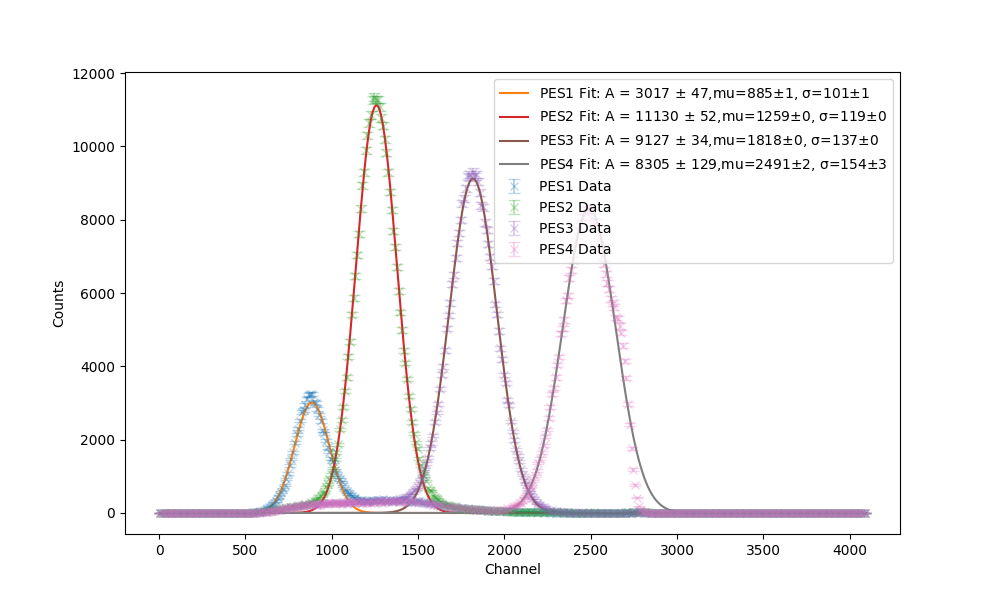

In [38]:
# PES1 = read_data('RawData/spectrum/PES_1.TKA', cutoff = 2)
# PES1_channels = np.arange(2, 2 + len(PES1))

# PES1_uncertainty = np.sqrt(PES1)

# # bin data
# PES1_channels, PES1, PES1_err = bin_data_poisson(PES1_channels, PES1, PES1_uncertainty, 10)

# # mask fitting range
# mask_PES1 = (PES1_channels > 890) & (PES1_channels < 1300) & (PES1 > 0)

# # fit gaussian
# popt_PES1, pcov_PES1 = curve_fit(gauss, PES1_channels[mask_PES1], PES1[mask_PES1], sigma = PES1_err[mask_PES1], p0 = [np.max(PES1), PES1_channels[np.argmax(PES1)], 150])

# plt.figure()
# plt.errorbar(PES1_channels, PES1, yerr = PES1_err, fmt='x', capsize=4, label='Data', alpha = 0.3)
# plt.plot(PES1_channels, gauss(PES1_channels, *popt_PES1), 'r-', label = f'Fit: mu = {popt_PES1[1]:.0f} $\pm$ {np.sqrt(pcov_PES1[1,1]):.0f}, sigma = {popt_PES1[2]:.0f} $\pm$ {np.sqrt(pcov_PES1[2,2]):.0f}')
# plt.legend()
# plt.xlabel('Channel')
# plt.ylabel('Counts')


files = [
    # 'RawData/spectrum/PES_1.TKA',
    #      'RawData/spectrum/PES_2.TKA',
    #      'RawData/spectrum/PES_3.TKA',
    #      'RawData/spectrum/PES_4.TKA',
    #      'RawData/spectrum/PES_5.TKA',
    #      'RawData/spectrum/PES_6.TKA',
         'RawData/spectrum/PES_7.TKA',
         'RawData/spectrum/PES_8.TKA',
         'RawData/spectrum/PES_9.TKA',
         'RawData/spectrum/PES_10.TKA']

# Masken für jede Datei individuell (Channel-Bereiche)
fit_masks = [
    # (890, 1300),  # PES1
    # (1200, 2000),  # PES2
    # (1550, 2500),  # PES3
    # (2000, 2600),   # PES4
    # (550, 1050),   # PES5
    # (800, 1500),   # PES6
    (600, 1100),   # PES7
    (1000, 1500),   # PES8
    (1550, 2200),   # PES9
    (2250, 2750),   # PES10
]

bin_width = 10

plt.figure(figsize=(10, 6))

for i, (file, mask_range) in enumerate(zip(files, fit_masks), 1):
    # Daten einlesen
    PES = read_data(file, cutoff=2)
    PES_channels = np.arange(2, 2 + len(PES))
    PES_uncertainty = np.sqrt(PES)
    
    # Daten binned
    PES_channels_b, PES_b, PES_err_b = bin_data_poisson(PES_channels, PES, PES_uncertainty, bin_width)
    
    # Fitting-Maske individuell
    print(mask_range)
    mask = (PES_channels_b > mask_range[0]) & (PES_channels_b < mask_range[1]) & (PES_b > 0)
    
    # Initial guess: Amplitude, Mittelwert, Sigma
    masked_channels = PES_channels_b[mask]
    masked_counts = PES_b[mask]

    max_index = np.argmax(masked_counts)
    mu_guess = masked_channels[max_index]

    p0 = [masked_counts[max_index], mu_guess, 150]
    
    # Gaussian Fit
    popt, pcov = curve_fit(gauss, PES_channels_b[mask], PES_b[mask], sigma=PES_err_b[mask], p0=p0)
    
    # Plot Daten + Fit
    plt.errorbar(PES_channels_b, PES_b, yerr=PES_err_b, fmt='x', capsize=4, alpha=0.3, label=f'PES{i} Data')
    plt.plot(PES_channels_b, gauss(PES_channels_b, *popt), '-', label=f'PES{i} Fit: A = {popt[0]:.0f} $\pm$ {np.sqrt(pcov[0,0]):.0f},mu={popt[1]:.0f}$\pm${np.sqrt(pcov[1,1]):.0f}, σ={popt[2]:.0f}$\pm${np.sqrt(pcov[2,2]):.0f}')

plt.xlabel('Channel')
plt.ylabel('Counts')
plt.legend()
plt.show()


## Pedestal Measurement
hier poisson statistik mit iminuit

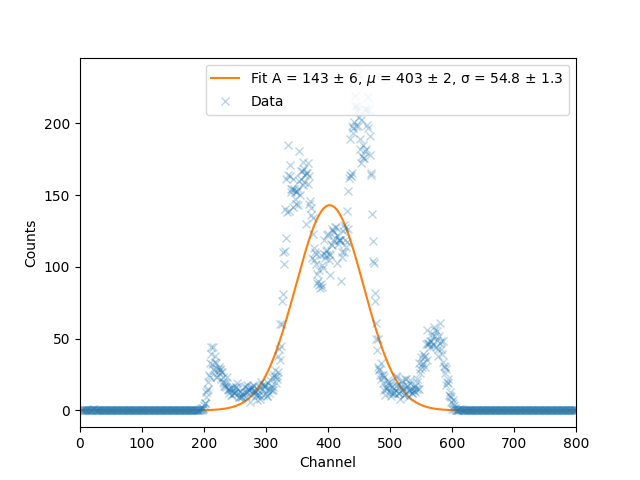

In [114]:
pedestal_1 = read_data('RawData/spectrum/pedestal_1.TKA', cutoff=2)
pedestal_1_channel = np.arange(2, 2 + len(pedestal_1))

# chose range
mask = (pedestal_1_channel > 200) & (pedestal_1_channel < 600) #& (pedestal_1 > 0)

# fit gauss
popt_pedestal, pcov_pedestal = curve_fit(gauss, pedestal_1_channel[mask], pedestal_1[mask], sigma=np.sqrt(pedestal_1[mask]), p0=[200, 400, 10])

mu_pedestal = popt_pedestal[1]
sigma_pedestal = popt_pedestal[2]

plt.figure()
plt.errorbar(pedestal_1_channel, pedestal_1, fmt='x', capsize=4, label='Data', alpha=0.3)
plt.plot(pedestal_1_channel, gauss(pedestal_1_channel, *popt_pedestal), label=f'Fit A = {popt_pedestal[0]:.0f} ± {np.sqrt(pcov_pedestal[0,0]):.0f}, $\mu$ = {popt_pedestal[1]:.0f} ± {np.sqrt(pcov_pedestal[1,1]):.0f}, σ = {popt_pedestal[2]:.1f} ± {np.sqrt(pcov_pedestal[2,2]):.1f}')
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.xlim(0, 800)
plt.legend()
plt.show()


In [116]:



# Minuit mit Startwerten initialisieren
m = Minuit(nll([A, mu, sigma],pedestal_1_channel[mask], pedestal_1[mask], gauss), A=200.0, mu=400.0, sigma=10.0)
m.limits['A'] = (0, None)       # Amplitude und sigma sollen positiv sein
m.limits['sigma'] = (0, None)

# Minimierung und Fehlerabschätzung
m.migrad()
m.hesse()  # berechnet Kovarianzmatrix

A_hat, mu_hat, sigma_hat = m.values
A_err, mu_err, sigma_err = m.errors

print(f"A = {A_hat:.1f} ± {A_err:.1f}, μ = {mu_hat:.1f} ± {mu_err:.1f}, σ = {sigma_hat:.1f} ± {sigma_err:.1f}")


# Fitwerte bereits berechnet
lam_fit = gauss(pedestal_1_channel, A_hat, mu_hat, sigma_hat)

# Residuen und Fehler (Poisson)
residues = pedestal_1 - lam_fit
resid_errors = np.sqrt(pedestal_1)

# Figure mit zwei Achsen (2:1 Verhältnis)
fig = plt.figure(figsize=(8,6))
gs = GridSpec(3, 1, height_ratios=[2, 1, 0.05])  # letzte Zeile für Abstand
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

# Oberer Plot: Daten + Fit
ax0.errorbar(pedestal_1_channel, pedestal_1, yerr=np.sqrt(pedestal_1), fmt='x', capsize=4, label='Data', alpha=0.5)
ax0.plot(pedestal_1_channel, lam_fit, color='red',
         label=f'Fit A = {A_hat:.1f} ± {A_err:.1f}, μ = {mu_hat:.1f} ± {mu_err:.1f}, σ = {sigma_hat:.1f} ± {sigma_err:.1f}')
ax0.set_ylabel('Counts')
ax0.legend()
ax0.set_xlim(0, 800)

# Unterer Plot: Residuen
ax1.errorbar(pedestal_1_channel, residues, yerr=resid_errors, fmt='x', capsize=3)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Residuals')
ax1.set_xlim(0, 800)

NameError: name 'A' is not defined

In [63]:
pedestal_100 = mu_hat
dpedestal_100 = mu_err
pedestal_50 = pedestal_100 * 0.5
dpedestal_50 = dpedestal_100 * 0.5
pedestal_25 = pedestal_100 * 0.25
dpedestal_25 = dpedestal_100 * 0.25
pedestal_63 = pedestal_100 * 0.63
dpedestal_63 = dpedestal_100 * 0.63



## Fly-Through-Spectrum

In [93]:
def process_flythrough(filename, fit_range=(1000, 2500), bin_width=6, initial_guess=None, uncertainty_digits = [1, 1, 1, 2], dt_spectrometer=dt_spectrometer, plot=True):
    """
    Loads flythrough data, normalizes it, calculates uncertainties, bins the data,
    performs a Langauss fit on a specified range, and returns the fit parameters.
    The plot shows the entire measurement, with the fit displayed normally within the fit range and semi-transparently outside it.
    args:
        filename (str): path to the data file
        fit_range (tuple) (default: (1000, 2500)): range of channels to fit
        bin_width (int) (default: 6): width of the bins
        initial_guess (array) (default: None): initial guess for the fit parameters
        uncertainty_digits (array) (default: [1, 1, 1, 2]): uncertainty digits in order [mpv, xi, sigma, scale]
        dt_spectrometer (float) (default: 0.3): spectrometer uncertainty
        plot (bool) (default: True): whether to plot the data

    return: 

        popt, perr (array): fitted parameter and uncertainty
        x_binned_fit, y_binned_fit, y_err_fit (arrays): binned data for fit range, to avoid trouble with curve_fit, only data with counts unequal 0 are masked
        x_full, y_full, y_err_full (arrays): binned data for full range
    """

    # --- Daten einlesen ---
    data = read_data(filename, cutoff=2)
    time = read_data(filename, cutoff=0)[0]

    # Normalisieren
    rate = data / time
    d_rate = uncertainty_rate(rate, time, dt_spectrometer)

    channels = np.arange(2, 2 + len(rate))


    # --- Fitbereich auswählen ---
    fit_mask = (channels >= fit_range[0]) & (channels <= fit_range[1])
    x_fit = channels[fit_mask]
    y_fit = rate[fit_mask]
    dy_fit = d_rate[fit_mask]

    # Binning für den Fit
    x_binned_fit, y_binned_fit, y_err_fit = bin_data_poisson(x_fit, y_fit, dy_fit, bin_width)
    valid_mask = (y_err_fit >0) & np.isfinite(y_err_fit) & np.isfinite(y_binned_fit)

    
    x_binned_fit = x_binned_fit[valid_mask]
    y_binned_fit = y_binned_fit[valid_mask]
    y_err_fit = y_err_fit[valid_mask]

    # Startwerte
    if initial_guess is None:
        initial_guess = [1500.0, 80.0, 30.0, 200.0]

    # Fit durchführen
    popt, pcov = curve_fit(fit_langauss, x_binned_fit, y_binned_fit, p0=initial_guess, sigma=y_err_fit)
    perr = np.sqrt(np.diag(pcov))
    

    # --- Binning für den gesamten Plot (ohne Maske) ---
    x_full, y_full, y_err_full = bin_data_poisson(channels, rate, d_rate, bin_width)
    y_err_full[y_err_full == 0] = 0

    # --- Plot ---
    if plot:
        mpv, xi, sigma, A = popt
        mpv_err, xi_err, sigma_err, A_err = perr
        label_text = (
            f"Langauss Fit (range {fit_range[0]}-{fit_range[1]})\n"
            f"MPV = {mpv:.{uncertainty_digits[0]}f} ± {mpv_err:.{uncertainty_digits[0]}f}\n"
            f"ξ = {xi:.{uncertainty_digits[1]}f} ± {xi_err:.{uncertainty_digits[1]}f}\n"
            f"σ = {sigma:.{uncertainty_digits[2]}f} ± {sigma_err:.{uncertainty_digits[2]}f}\n"
            f"A = {A:.{uncertainty_digits[3]}f} ± {A_err:.{uncertainty_digits[3]}f}"
        )

        plt.figure(figsize=(8,5))
        plt.errorbar(x_full, y_full, yerr=y_err_full, fmt='x', alpha = 0.4, label='Data (binned, full range)')

        # Fitbereich normal
        plt.plot(x_binned_fit, fit_langauss(x_binned_fit, *popt), 'r-', label=label_text)

        # Außerhalb Fitbereich halbtransparent: links
        left_mask = x_full < fit_range[0]
        plt.plot(x_full[left_mask], fit_langauss(x_full[left_mask], *popt), 'r-', alpha=0.3)

        # Außerhalb Fitbereich halbtransparent: rechts
        right_mask = x_full > fit_range[1]
        plt.plot(x_full[right_mask], fit_langauss(x_full[right_mask], *popt), 'r-', alpha=0.3)

        plt.xlabel("Channel")
        plt.ylabel("Rate [1/s]")
        plt.legend()
        plt.show()

    return popt, perr, x_binned_fit, y_binned_fit, y_err_fit, x_full, y_full, y_err_full

TODO: wie propagiert der pedastal fehler in den fits? laut chatti in fit nur die y fehler berücksichtigen, und später erst die pedestal unsicherheit als systematischen fehler auf den MPV berücksichtigen, da pedestal keine zufälligen fehler pro punkt verursacht, sonder einen systematischen offset

### 100 % (8 dB)

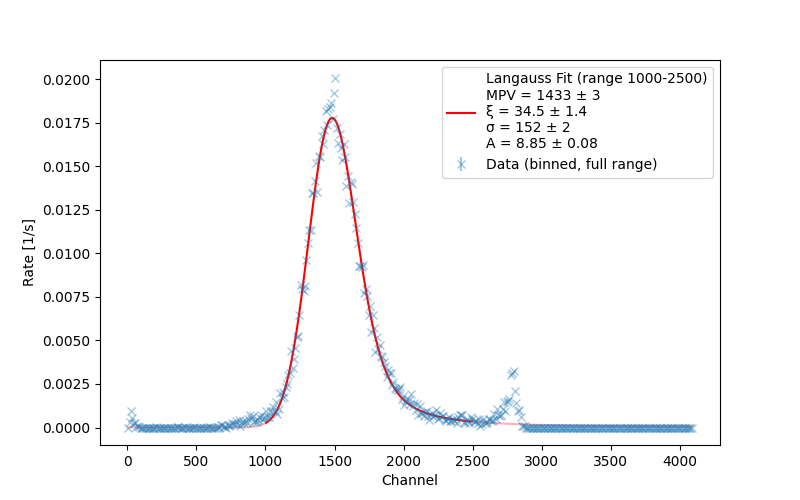

Gefittete Parameter: [1433.22926623   34.52934118  151.94364281    8.85325014]
Fehler der Parameter: [2.60992342 1.44020808 2.3576705  0.07957139]
pedestal corrected
mpv: 1023.2517012461253 $\pm$ 2.713969230927962  


In [106]:
mpv_all_values = []
dmpv_all_values = []

popt_100, perr_100, x_binned_fit_100, y_binned_fit_100, y_err_fit_100, x_full_100, y_full_100, y_err_full_100 = process_flythrough(
    'RawData/spectrum/flythrough_1.TKA',
    fit_range=(1000, 2500),
    bin_width=10, uncertainty_digits=[0, 1, 0, 2]#initial_guess = [370.0, 10.0, 8.0, 1.0]
)

print("Gefittete Parameter:", popt_100)
print("Fehler der Parameter:", perr_100)

print('pedestal corrected')

print(fr'mpv: {popt_100[0] - pedestal_100} $\pm$ {np.sqrt(perr_100[0]**2 + dpedestal_100**2)}  ')

mpv_all_values.append(popt_100[0] - pedestal_100)
dmpv_all_values.append(np.sqrt(perr_100[0]**2 + dpedestal_100**2))

In [107]:
print(y_err_fit_100)

[1.33156192e-06 1.21554317e-06 1.29404696e-06 1.25540855e-06
 1.50518267e-06 1.53755590e-06 1.29404527e-06 1.80294773e-06
 1.47209769e-06 1.17432554e-06 2.17444261e-06 1.80294693e-06
 2.15167316e-06 1.88311814e-06 2.10539186e-06 2.34867029e-06
 2.41075976e-06 2.60707937e-06 3.01040389e-06 2.80721022e-06
 2.71806620e-06 3.13856803e-06 3.35108379e-06 3.20073147e-06
 3.66018897e-06 4.10426904e-06 4.18743908e-06 4.10427063e-06
 4.26898278e-06 4.29200391e-06 4.79094027e-06 4.84206908e-06
 4.87250813e-06 5.31725039e-06 5.32651594e-06 5.50837104e-06
 5.64092817e-06 5.40910730e-06 5.65836604e-06 5.91379132e-06
 5.66706742e-06 6.04561976e-06 6.03745417e-06 6.20644248e-06
 6.15863193e-06 6.15063997e-06 6.33218545e-06 6.25389306e-06
 6.22230161e-06 6.16663459e-06 6.71728695e-06 5.99652746e-06
 5.97182133e-06 5.92211711e-06 5.96357152e-06 5.63218796e-06
 5.88875043e-06 5.82143955e-06 5.57063027e-06 5.63218873e-06
 5.23321106e-06 5.34497620e-06 5.53514466e-06 5.25200046e-06
 5.24261737e-06 4.942759

Best‑fit‑Parameter (symmetrisch):
MPV = 1430.653 ± 455.939
  ξ = 36.390 ± 220.243
  σ = 153.427 ± 252.577
  A = 9.021 ± 9.921


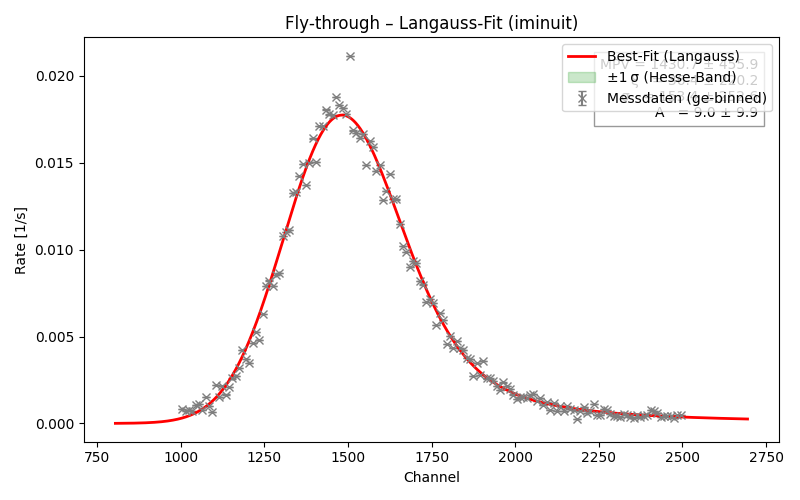

[nan nan nan ... nan nan nan]
[0.00059395 0.00059669 0.00059945 ... 0.00626282 0.00625636 0.0062499 ]


In [ ]:
# fit with iminuit

popt, perr, minuit = fit_with_iminuit(
    x_binned_fit_100,
    y_binned_fit_100,
    model=fit_langauss,
    p0=[1500, 80, 30, 200],          # [mpv, xi, sigma, A]
    bounds=[(0, None), (0, None), (1e-3, None), (0, None)],
    verbose=False,
    asymmetric=False
)

print("Best‑fit‑Parameter (symmetrisch):")
for name, val, err in zip(['MPV', 'ξ', 'σ', 'A'], popt, perr):
    print(f"{name:>3} = {val:.3f} ± {err:.3f}")

# --------------------------------------------------------------
# 1.  Daten (binned) und Fit‑Parameter – du hast sie bereits:
# --------------------------------------------------------------
# x_binned_fit_100 : Kanal‑Mittelpunkte im Fit‑Bereich (1‑D array)
# y_binned_fit_100 : gemessene Rate (1‑D array)
# popt            : beste Parameter [mpv, xi, sigma, A]
# perr            : symmetrische 1‑σ‑Fehler (Hesse)
# fit_langauss    : deine Modell‑Funktion  (A·exp(…) o.ä.)
# --------------------------------------------------------------

# 2.  Modellkurve über das gesamte Plot‑Intervall erzeugen
x_dense = np.linspace(x_binned_fit_100.min() - 200,
                      x_binned_fit_100.max() + 200,
                      2000)                     # feine Auflösung
y_fit_dense = fit_langauss(x_dense, *popt)

# 3.  ±1 σ‑Band (optional – basiert auf symmetrischen Hesse‑Fehlern)
#    Wir variieren jeden Parameter um ±1 σ und bilden die maximale
#    Abweichung nach oben/unten, um ein einfaches Band zu erhalten.
if perr is not None:
    # Ober‑ und Unter‑Kurve erzeugen
    y_upper = fit_langauss(x_dense,
                           *(popt + perr))   # Alle Parameter +σ
    y_lower = fit_langauss(x_dense,
                           *(popt - perr))   # Alle Parameter -σ
else:
    y_upper = y_lower = y_fit_dense          # kein Band, falls perr fehlt

# 4.  Plot
plt.figure(figsize=(8, 5))

# 4.1  Datenpunkte mit Fehlerschätzung (Poisson – √k)
#      Wir benutzen die bereits gebinnten Fehler (`y_err_fit_100`),
#      falls du sie noch hast:
#      y_err_fit_100 = np.sqrt(y_binned_fit_100)   # Beispiel
# (Falls du die Fehler schon berechnet hast, ersetze die Zeile unten.)
#y_err_fit_100 = np.sqrt(np.abs(y_binned_fit_100))   # nur als Platzhalter

plt.errorbar(
    x_binned_fit_100,
    y_binned_fit_100,
    yerr=y_err_fit_100,
    fmt='x',
    color='tab:gray',
    ecolor='tab:gray',
    capsize=3,
    label='Messdaten (ge‑binned)'
)

# 4.2  Fit‑Kurve
plt.plot(x_dense, y_fit_dense, 'r-', lw=2, label='Best‑Fit (Langauss)')

# 4.3  ±1 σ‑Band als halbtransparentes Grün (optional)
plt.fill_between(x_dense, y_lower, y_upper,
                 color='tab:green', alpha=0.25,
                 label='±1 σ (Hesse‑Band)')

# 4.4  Achsenbeschriftungen
plt.xlabel('Channel')
plt.ylabel('Rate [1/s]')
plt.title('Fly‑through – Langauss‑Fit (iminuit)')

# 4.5  Parameter‑Text (kann auch als Legende oder im Plot‑Titel stehen)
fit_text = (
    f"MPV = {popt[0]:.1f} ± {perr[0]:.1f}\n"
    f"ξ   = {popt[1]:.1f} ± {perr[1]:.1f}\n"
    f"σ   = {popt[2]:.1f} ± {perr[2]:.1f}\n"
    f"A   = {popt[3]:.1f} ± {perr[3]:.1f}"
)
plt.legend(loc='upper right')
# Wir nutzen `plt.text` für die Parameter‑Info im Plot
plt.text(0.97, 0.95, fit_text,
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()


In [113]:
print(popt - perr)

[ 9.74714530e+02 -1.83852629e+02 -9.91497028e+01 -8.99942545e-01]


### 25 % (20 dB)

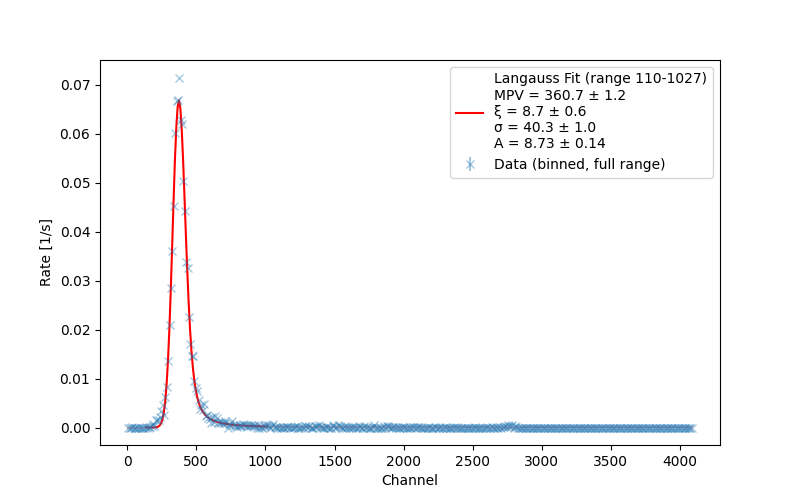

Gefittete Parameter: [360.66063054   8.71712337  40.34857276   8.72784733]
Fehler der Parameter: [1.1934404  0.57118429 1.04108835 0.1449846 ]


In [10]:
popt_25, perr_25, x_binned_fit_25, y_binned_fit_25, y_err_fit_25, x_full_25, y_full_25, y_err_full_25 = process_flythrough(
    'RawData/spectrum/flythrough_2.TKA',
    fit_range=(110, 1027),
    bin_width=10, initial_guess = [370.0, 10.0, 8.0, 1.0], uncertainty_digits=[1, 1, 1, 2]
)

print("Gefittete Parameter:", popt_25)
print("Fehler der Parameter:", perr_25)

mpv_all_values.append(popt_25[0] - pedestal_25)
dmpv_all_values.append(np.sqrt(perr_25[0]**2 + dpedestal_25**2))

### 50 % (14 dB)

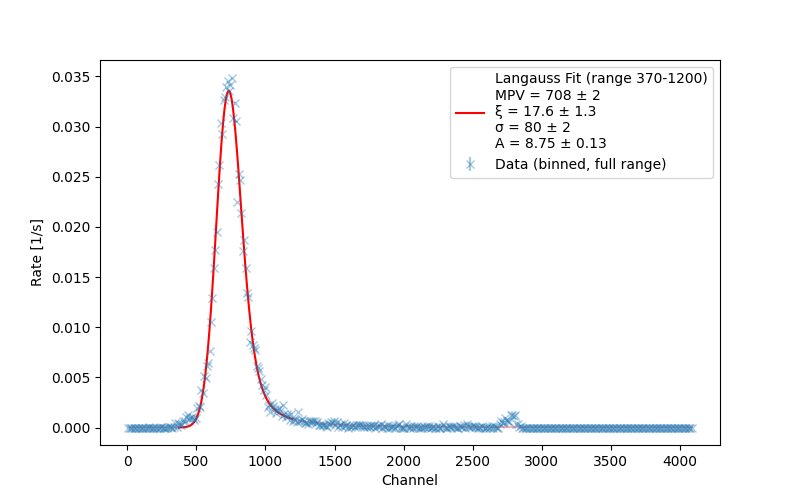

Gefittete Parameter: [708.28257835  17.59810958  80.1083687    8.74505988]
Fehler der Parameter: [2.35684188 1.34668039 2.08297426 0.13209794]


In [11]:
popt_50, perr_50, x_binned_fit_50, y_binned_fit_50, y_err_fit_50, x_full_50, y_full_50, y_err_full_50 = process_flythrough(
    'RawData/spectrum/flythrough_3.TKA',
    fit_range=(370, 1200),
    bin_width=10, initial_guess = [780.0, 10.0, 8.0, 1.0], uncertainty_digits=[0, 1, 0, 2]
)

print("Gefittete Parameter:", popt_50)
print("Fehler der Parameter:", perr_50)

mpv_all_values.append(popt_50[0] - pedestal_50)
dmpv_all_values.append(np.sqrt(perr_50[0]**2 + dpedestal_50**2))

### ~63 % 12 dB

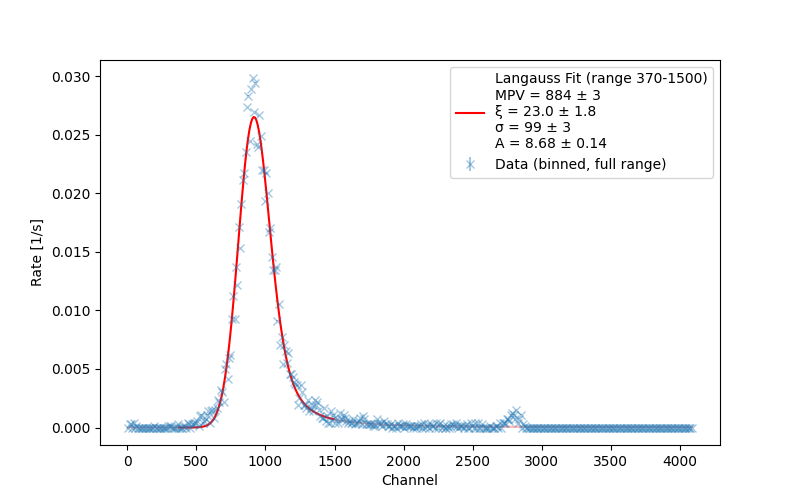

Gefittete Parameter: [884.46128396  22.97015574  99.44507608   8.68063052]
Fehler der Parameter: [3.1066827  1.83297561 2.82827971 0.13929701]


In [12]:
popt_63, perr_63, x_binned_fit_63, y_binned_fit_63, y_err_fit_63, x_full_63, y_full_63, y_err_full_63 = process_flythrough(
    'RawData/spectrum/flythrough_5.TKA',
    fit_range=(370, 1500),
    bin_width=10, initial_guess = [780.0, 10.0, 8.0, 1.0], uncertainty_digits=[0, 1, 0, 2]
)

print("Gefittete Parameter:", popt_63)
print("Fehler der Parameter:", perr_63)

mpv_all_values.append(popt_63[0] - pedestal_63)
dmpv_all_values.append(np.sqrt(perr_63[0]**2 + dpedestal_63**2))

In [13]:
MIP_rhox = 1.95 # MeV cm^2 g^-1
rho = 0.87 # g cm^-3 density of liquid scintillator
s = 85 # cm mean free path in tank

dMIP_rhox = 0.05
drho = 0.01
ds = 5 

energy_MIP = MIP_rhox * rho * s
denergy_MIP = np.sqrt((dMIP_rhox * rho * s)**2 + (MIP_rhox * drho * s)**2 + (MIP_rhox * rho * ds)**2)
print(energy_MIP, denergy_MIP)

energy_MIP_all = [energy_MIP, 0.25 * energy_MIP, 0.50 * energy_MIP, 0.63 * energy_MIP]
denergy_MIP_all = [denergy_MIP, 0.25 * denergy_MIP, 0.50 * denergy_MIP, 0.63 * denergy_MIP]


144.2025 9.400617998302026


m = 0.11386113604900434 ± 0.001720158670354068
b = -0.7879737633868821 ± 0.9091494400699748


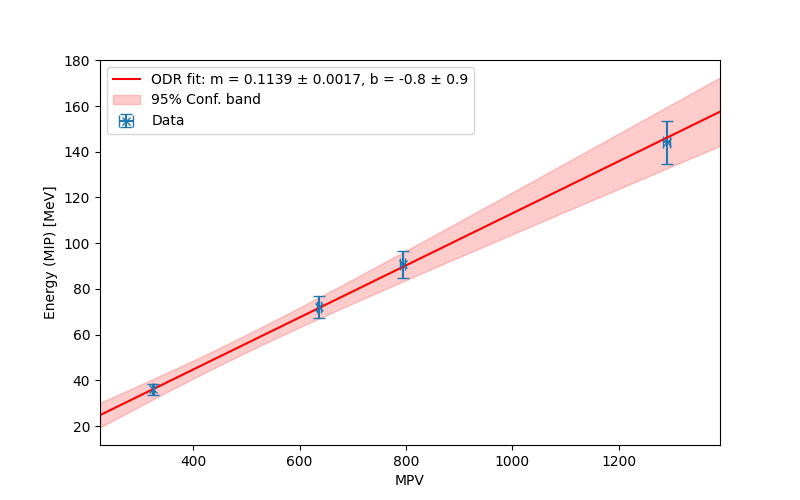

In [14]:
# Datenobjekt mit Unsicherheiten
data = RealData(
    mpv_all_values,
    energy_MIP_all,
    sx=dmpv_all_values,
    sy=denergy_MIP_all
)

# Modell
model = Model(linear_func)

# Initial guesses
beta0 = [1, 0]

# ODR
odr = ODR(data, model, beta0=beta0)
out = odr.run()

# Fitparameter
m_energycalib, b_energycalib = out.beta
dm_energycalib, db_energycalib = out.sd_beta

print(f"m = {m_energycalib} ± {dm_energycalib}")
print(f"b = {b_energycalib} ± {db_energycalib}")

# Fitkurve
x_fit = np.linspace(min(mpv_all_values)-100, max(mpv_all_values)+100, 500)
y_fit = m_energycalib*x_fit + b_energycalib

# Kovarianzmatrix aus ODR
cov = out.cov_beta  # 2x2 Matrix: [[var_m, cov_mb],[cov_mb, var_b]]
var_m = cov[0,0]
var_b = cov[1,1]
cov_mb = cov[0,1]

# Unsicherheit auf y(x)
sigma_y = np.sqrt(var_b + (x_fit**2)*var_m + 2*x_fit*cov_mb)

# 95% Konfidenzband
t = 1.96
y_upper = y_fit + t*sigma_y
y_lower = y_fit - t*sigma_y

# Plot
plt.figure(figsize=(8,5))
plt.errorbar(
    mpv_all_values,
    energy_MIP_all,
    xerr=dmpv_all_values,
    yerr=denergy_MIP_all,
    fmt='x',
    capsize=4,
    label='Data'
)
plt.plot(x_fit, y_fit, 'r', label=f'ODR fit: m = {m_energycalib:.4f} ± {dm_energycalib:.4f}, b = {b_energycalib:.1f} ± {db_energycalib:.1f}')
plt.fill_between(x_fit, y_lower, y_upper, color='red', alpha=0.2, label='95% Conf. band')
plt.xlabel("MPV")
plt.ylabel("Energy (MIP) [MeV]")
plt.xlim(min(mpv_all_values)-100, max(mpv_all_values)+100)
plt.legend()
plt.show()

In [15]:
def channel_to_energy_with_error(channel, m = m_energycalib, b = b_energycalib, dm = dm_energycalib, db = db_energycalib, dchannel=0):
    """
    Kalibrierungsfunktion mit vollständiger Unsicherheitsabschätzung

    Parameters
    ----------
    channel : float or array-like
        Kanalwerte
    m, b : float
        Fit-Parameter der Kalibration
    dm, db : float
        Unsicherheiten der Fit-Parameter
    dchannel : float or array-like
        Unsicherheit der Kanalwerte (z.B. Pedestal-Fehler)

    Returns
    -------
    energy : float or array-like
        Energie
    energy_err : float or array-like
        Unsicherheit der Energie
    """
    channel = np.array(channel)

    energy = m * channel + b

    energy_err = np.sqrt(
        (m * dchannel)**2 +  
        (channel * dm)**2 +
        db**2
    )

    return energy, energy_err

## Time Spectrum Calibration

Delay = 2.44 ± 0.0022 µs


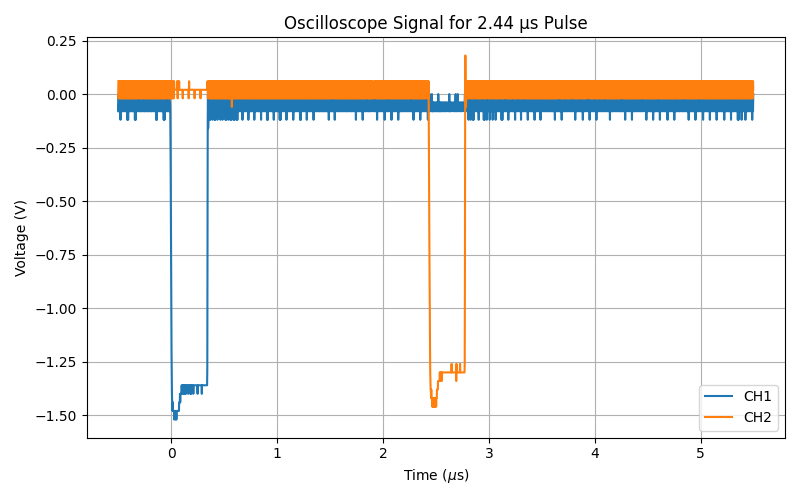

Delay = 4.54 ± 0.0019 µs


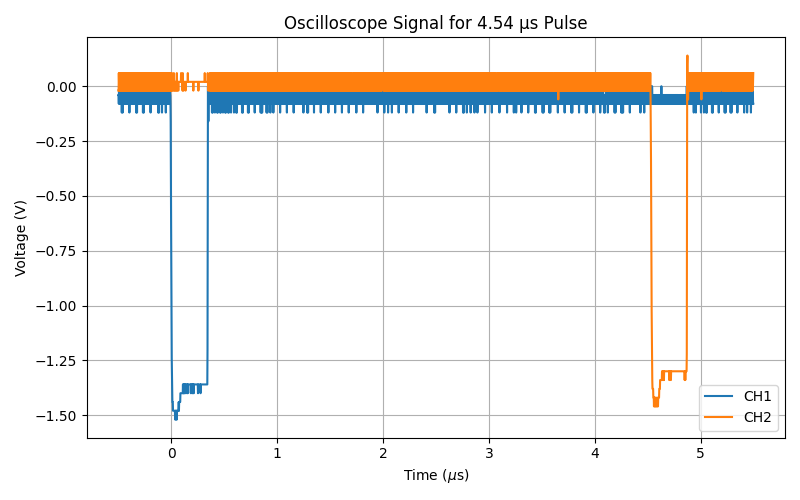

Delay = 6.29 ± 0.0023 µs


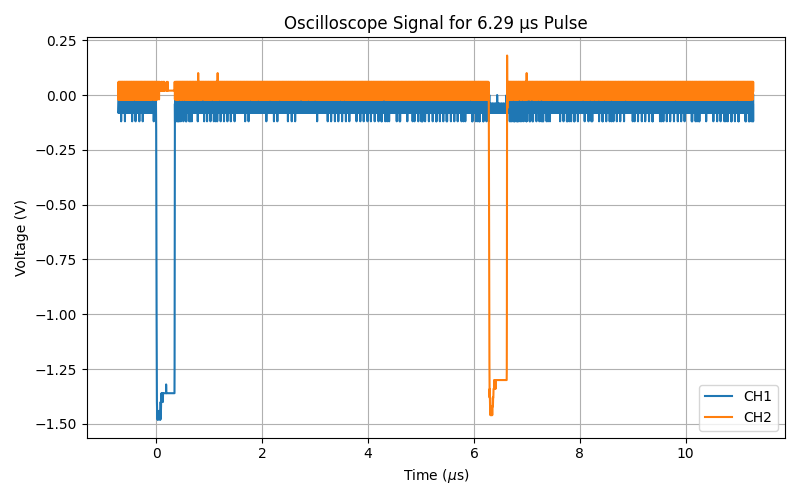

Delay = 8.65 ± 0.0024 µs


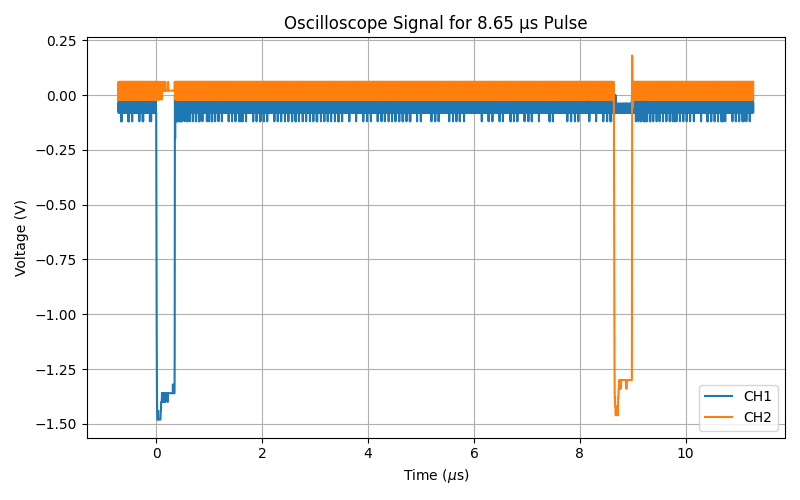

Delay = 10.69 ± 0.0024 µs


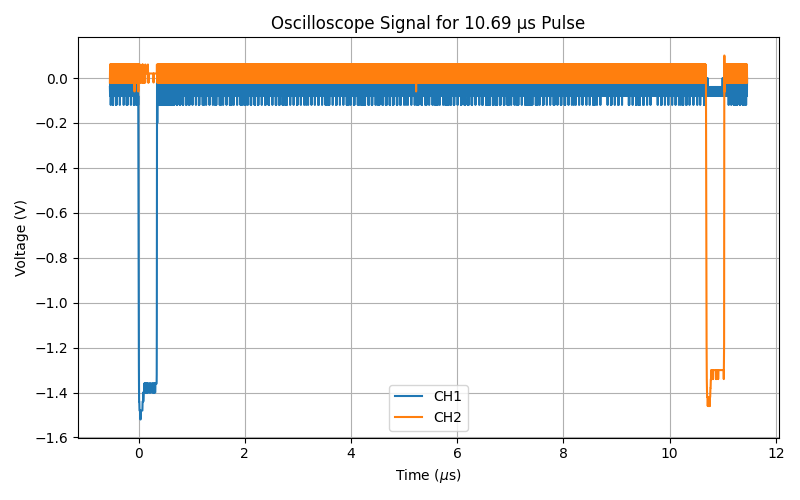

In [16]:
files = ["NewFile1.csv", "NewFile2.csv", "NewFile3.csv", "NewFile4.csv", "NewFile5.csv"]
pulse_times_us = [2, 4, 6, 8, 10]  # in µs
delay_values = []
delay_unc = []

for file in files:

    t, ch1, ch2 = load_rigol_two_channel(f"RawData/timecalib5/{file}")

    # 50 %
    t1_50 = threshold_time(t, ch1, 0.5)
    t2_50 = threshold_time(t, ch2, 0.5)

    # 40 %
    t1_40 = threshold_time(t, ch1, 0.4)
    t2_40 = threshold_time(t, ch2, 0.4)

    # 60 %
    t1_60 = threshold_time(t, ch1, 0.6)
    t2_60 = threshold_time(t, ch2, 0.6)

    delay = t2_50 - t1_50

    sigma_t1 = abs(t1_60 - t1_40) / 2
    sigma_t2 = abs(t2_60 - t2_40) / 2

    sigma_delay = np.sqrt(sigma_t1**2 + sigma_t2**2)

    print(f"Delay = {delay*1e6:.2f} ± {sigma_delay*1e6:.4f} µs")

    delay_values.append(delay)
    delay_values_us = np.array([i*1e6 for i in delay_values])
    delay_unc.append(sigma_delay)
    delay_unc_us= np.array([i*1e6 for i in delay_unc])
    plt.figure(figsize=(8,5)) 
    plt.plot(t*1e6, ch1, label="CH1") 
    plt.plot(t*1e6, ch2, label="CH2") 
    plt.xlabel("Time ($\mu$s)") 
    plt.ylabel("Voltage (V)") 
    plt.title(f"Oscilloscope Signal for {delay*1e6:.2f} µs Pulse") 
    plt.savefig(f'timecalib4{delay*1e6}.pdf')
    plt.legend() 
    plt.grid() 
    plt.tight_layout() 
    plt.show()

[910, 1643, 2254, 3079, 3791]


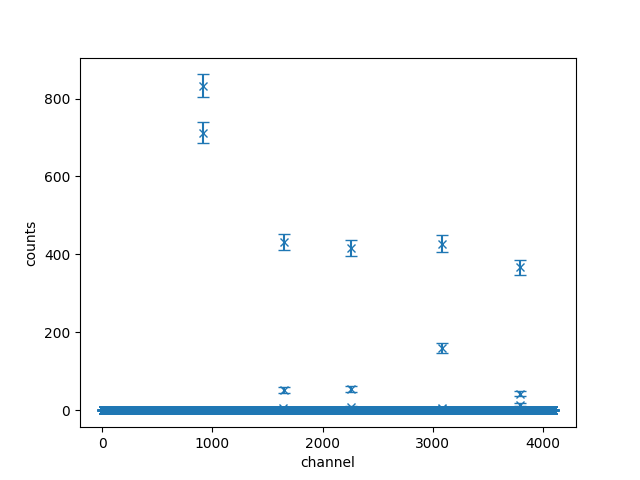

In [18]:
# import time calibration spectrum

time_calibration_spectrum = read_data('RawData/spectrum/time_calibration_5.TKA', cutoff = 2) # 2
time_calibration_channel = np.arange(2, 2 + len(time_calibration_spectrum))
time_calibration_uncertainty = np.array([np.sqrt(x) for x in time_calibration_spectrum])

# find peaks
peaks = np.where(time_calibration_spectrum > 20)[0]

# Gruppen bilden
groups = []
current = [peaks[0]]

for p in peaks[1:]:
    if p - current[-1] <= 1:
        current.append(p)
    else:
        groups.append(current)
        current = [p]

groups.append(current)

peaks_calibration_time = []
dpeaks_calibration_time = []

for g in groups:
    g = np.array(g)

    heights = time_calibration_spectrum[g]

    # höhengewichteter Mittelwert
    mean = np.sum(g * heights) / np.sum(heights)

    # Unsicherheit aus halber Peakbreite
    unc = (np.max(g) - np.min(g)) / 2

    # ganze Channel
    unc = int(np.round(unc))
    mean = int(np.round(mean))

    peaks_calibration_time.append((mean))
    dpeaks_calibration_time.append((unc))

print(peaks_calibration_time)
dpeaks_calibration_time = [1, 1, 1, 1, 1]


#time_calibration_fit_results = []
plt.figure()
plt.errorbar(time_calibration_channel, time_calibration_spectrum, yerr=time_calibration_uncertainty, fmt='x', capsize=4)
plt.xlabel('channel')
plt.ylabel('counts')
plt.savefig('timecalib5.pdf')



#### curve fit fit

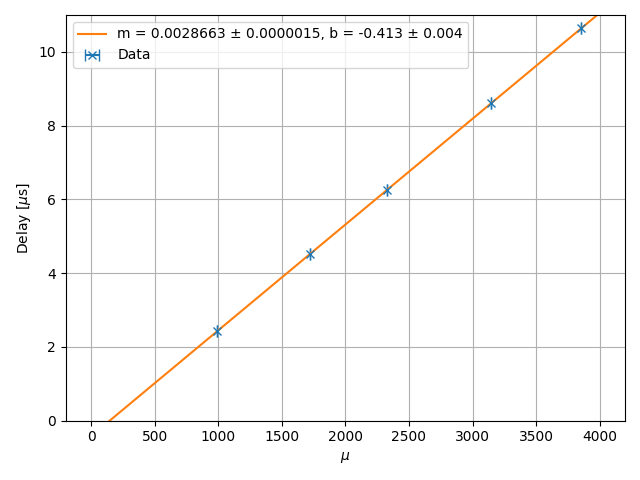

In [565]:
mean_time_calibration = peaks_calibration_time
error_mean_time_calibration = dpeaks_calibration_time

# perform linear fit
popt_timecalib, pcov_timecalib = curve_fit(
    linear,
    mean_time_calibration,     
    delay_values_us, 
    sigma=error_mean_time_calibration
)

m_timecalib, b_timecalib = popt_timecalib
dm_timecalib, db_timecalib = np.sqrt(np.diag(pcov_timecalib))

x_timecalib_plot = np.linspace(0, 4000, 100000)
y_timecalib_plot = linear(x_timecalib_plot, m_timecalib, b_timecalib)

# Plot mit vertauschten Achsen
plt.figure()
plt.errorbar(mean_time_calibration, delay_values_us, xerr=error_mean_time_calibration, fmt='x', capsize=4, label='Data')  
plt.plot(x_timecalib_plot, y_timecalib_plot, label=f'm = {m_timecalib:.7f} ± {dm_timecalib:.7f}, b = {b_timecalib:.3f} ± {db_timecalib:.3f}')
plt.xlabel('$\mu$')
plt.ylabel('Delay [$\mu$s]')
plt.ylim(0, 11)
#plt.xlim(2000, 4000)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#### ODR fit

Slope = 0.002864 ± 0.000002
Intercept = -0.17 ± 0.00


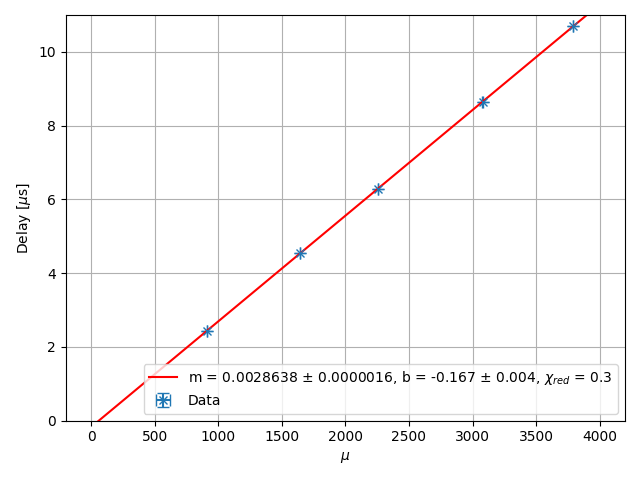

In [19]:
mean_time_calibration = peaks_calibration_time
error_mean_time_calibration = dpeaks_calibration_time


# RealData mit x-Fehler
data = RealData(mean_time_calibration, delay_values_us,
                sx=error_mean_time_calibration, sy=delay_unc_us)  # y-Fehler None, nur x-Fehler

# Modell und ODR-Objekt
linear_model = Model(linear_func)
odr = ODR(data, linear_model, beta0=[0.001, 0])  # Startwerte m, b

# Fit durchführen
output = odr.run()

m_odr, b_odr = output.beta
dm_odr, db_odr = np.sqrt(np.diag(output.cov_beta))

print(f"Slope = {m_odr:.6f} ± {dm_odr:.6f}")
print(f"Intercept = {b_odr:.2f} ± {db_odr:.2f}")

# Fit-Kurve für Plot
x_fit = np.linspace(0, 4000, 10000)
y_fit = linear_func([m_odr, b_odr], x_fit)

# Plot
plt.figure()
plt.errorbar(mean_time_calibration, delay_values_us, xerr=error_mean_time_calibration, yerr = delay_unc_us, fmt='x', capsize=4, label='Data')
plt.plot(x_fit, y_fit, 'r-', label=f'm = {m_odr:.7f} ± {dm_odr:.7f}, b = {b_odr:.3f} ± {db_odr:.3f}, $\chi_{{red}}$ = {output.res_var:.1f}')
plt.xlabel('$\mu$')
plt.ylabel('Delay [$\mu$s]')
plt.ylim(0, 11)
# plt.xlim(2000, 4000)
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('fit_timecalib5.pdf')
plt.show()

In [20]:
def mu_to_delay_with_error(mu, m, b, dm, db):
    """
    Kalibrierungsfunktion mit Unsicherheitsabschätzung.
    
    Parameters
    ----------
    mu : float or array-like
        Gemessener Mittelwert aus dem Channel (mu)
    m, b : float
        Fit-Parameter des linearen Fits
    dm, db : float
        Unsicherheiten der Fit-Parameter
    
    Returns
    -------
    delay : float or array-like
        Kalibrierter Delay-Wert in µs
    delay_err : float or array-like
        Unsicherheit des Delay-Werts in µs
    """
    mu = np.array(mu)  # für Arrays kompatibel
    delay = m * mu + b
    delay_err = np.sqrt( (mu * dm)**2 + db**2 )
    return delay, delay_err

#mu_to_delay_with_error(1991, m_odr, b_odr, dm_odr, db_odr)


### Calibration with Function Generator

Delay = 0.56 ± 0.0006 µs


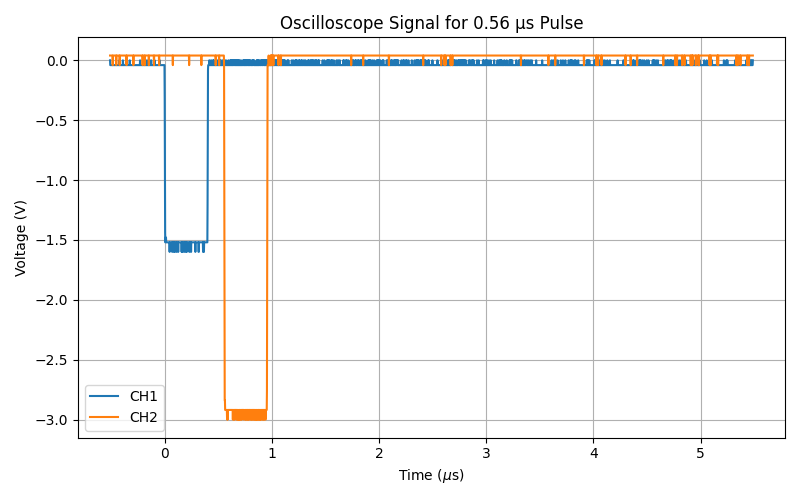

Delay = 1.11 ± 0.0006 µs


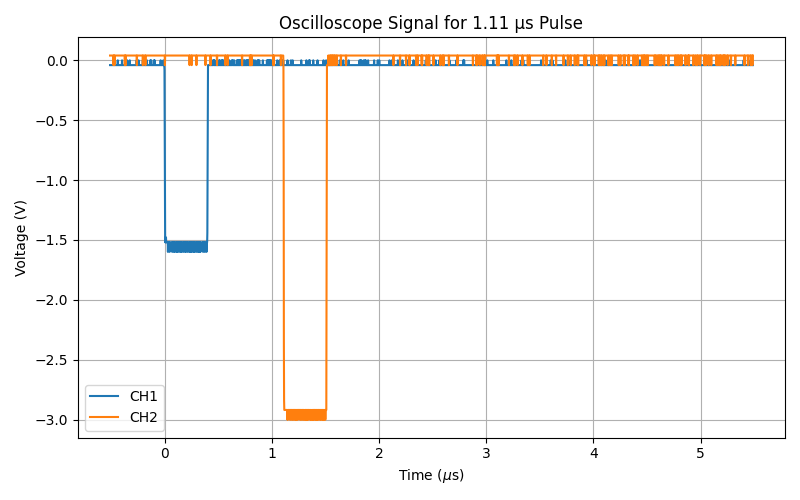

Delay = 1.67 ± 0.0006 µs


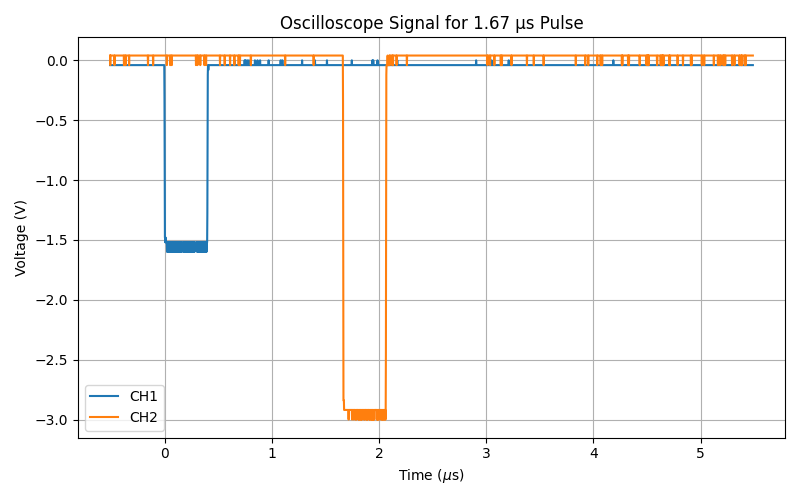

Delay = 2.22 ± 0.0006 µs


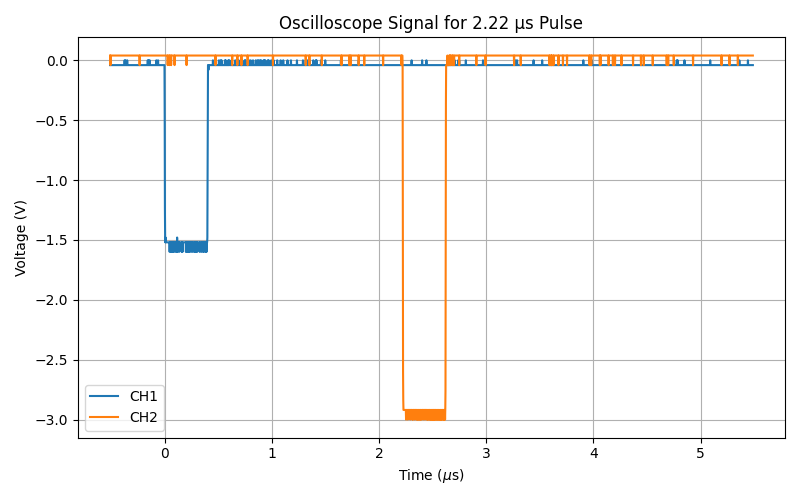

Delay = 2.78 ± 0.0006 µs


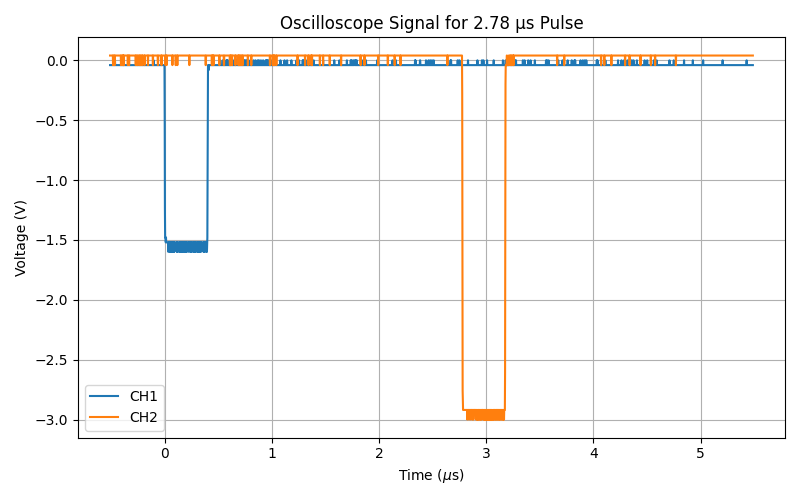

Delay = 5.55 ± 0.0006 µs


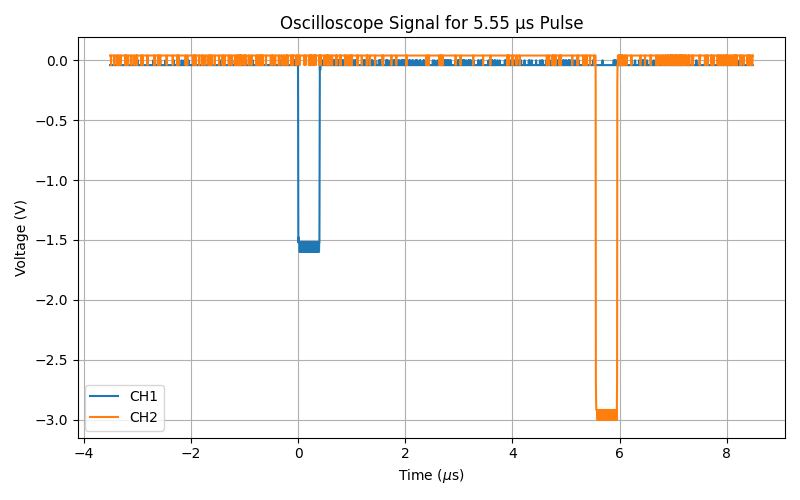

Delay = 8.34 ± 0.0015 µs


C:\Users\tabit\AppData\Local\Temp\ipykernel_24276\150861836.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,5))


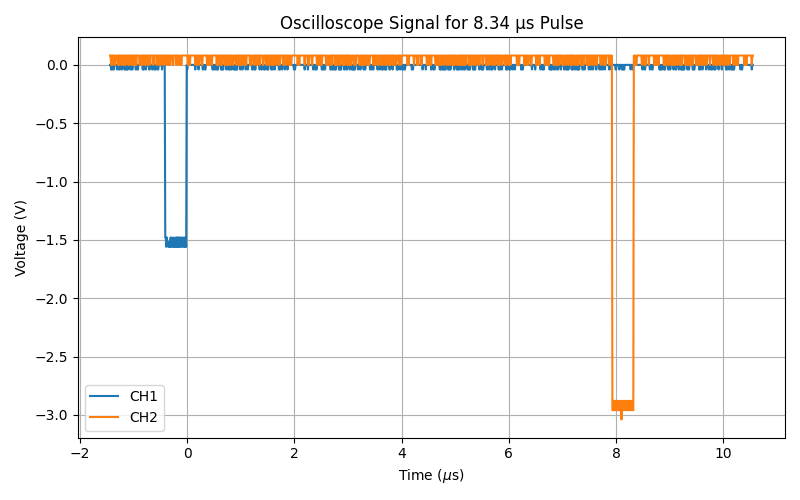

In [21]:
files = ["NewFile1.csv", "NewFile2.csv", "NewFile3.csv", "NewFile4.csv", "NewFile5.csv", "NewFile6.csv", "NewFile7.csv"]
#pulse_times_us = [2, 4, 6, 8, 10]  # in µs
delay_values_fg = []
delay_unc_fg = []


for file in files:

    t, ch1, ch2 = load_rigol_two_channel(f"RawData/timecalib3/{file}")

    # 50 %
    t1_50 = threshold_time(t, ch1, 0.5)
    t2_50 = threshold_time(t, ch2, 0.5)

    # 40 %
    t1_40 = threshold_time(t, ch1, 0.4)
    t2_40 = threshold_time(t, ch2, 0.4)

    # 60 %
    t1_60 = threshold_time(t, ch1, 0.6)
    t2_60 = threshold_time(t, ch2, 0.6)

    delay = t2_50 - t1_50

    sigma_t1 = abs(t1_60 - t1_40) / 2
    sigma_t2 = abs(t2_60 - t2_40) / 2

    sigma_delay = np.sqrt(sigma_t1**2 + sigma_t2**2)

    print(f"Delay = {delay*1e6:.2f} ± {sigma_delay*1e6:.4f} µs")

    delay_values_fg.append(delay)
    delay_values_us_fg = np.array([i*1e6 for i in delay_values_fg])
    delay_unc_fg.append(sigma_delay)
    delay_unc_us_fg = np.array([i*1e6 for i in delay_unc_fg])
    plt.figure(figsize=(8,5)) 
    plt.plot(t*1e6, ch1, label="CH1") 
    plt.plot(t*1e6, ch2, label="CH2") 
    plt.xlabel("Time ($\mu$s)") 
    plt.ylabel("Voltage (V)") 
    plt.title(f"Oscilloscope Signal for {delay*1e6:.2f} µs Pulse") 
    plt.legend() 
    plt.grid() 
    plt.tight_layout() 
    plt.show()

[5, 3, 2, 4, 4, 11, 2]


<ErrorbarContainer object of 3 artists>

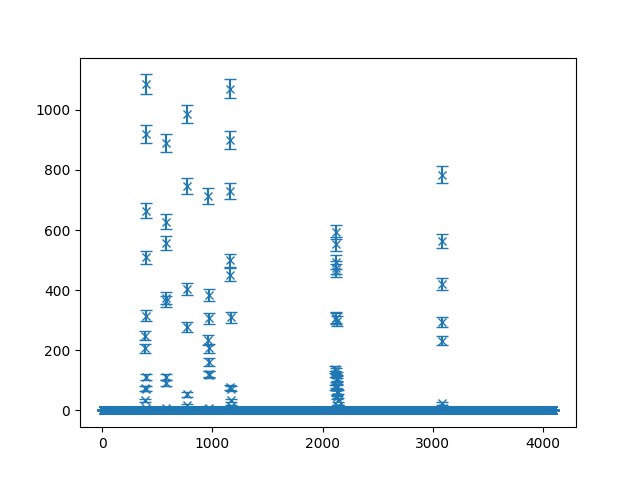

In [22]:
time_calibration_spectrum_fg = read_data('RawData/spectrum/time_calibration_3.TKA', cutoff = 2)
time_calibration_channel_fg = np.arange(2, 2 + len(time_calibration_spectrum_fg))
time_calibration_uncertainty_fg = np.array([np.sqrt(x) for x in time_calibration_spectrum_fg])

# find peaks
peaks_fg = np.where(time_calibration_spectrum_fg > 20)[0]

# Gruppen bilden
groups_fg = []
current_fg = [peaks_fg[0]]

for p in peaks_fg[1:]:
    if p - current_fg[-1] <= 1:
        current_fg.append(p)
    else:
        groups_fg.append(current_fg)
        current_fg = [p]

groups_fg.append(current_fg)

peaks_calibration_time_fg = []
dpeaks_calibration_time_fg = []

for g in groups_fg:
    g = np.array(g)

    heights_fg = time_calibration_spectrum_fg[g]

    # höhengewichteter Mittelwert
    mean_fg = np.sum(g * heights_fg) / np.sum(heights_fg)

    # Unsicherheit aus halber Peakbreite
    unc_fg = (np.max(g) - np.min(g)) / 2

    # ganze Channel
    unc_fg = int(np.round(unc_fg))
    mean_fg = int(np.round(mean_fg))

    peaks_calibration_time_fg.append((mean_fg))
    dpeaks_calibration_time_fg.append((unc_fg))

print(dpeaks_calibration_time_fg)

#dpeaks_calibration_time_fg = [1, 1, 1, 1, 1]


#time_calibration_fit_results = []
plt.figure()
plt.errorbar(time_calibration_channel_fg, time_calibration_spectrum_fg, yerr=time_calibration_uncertainty_fg, fmt='x', capsize=4)



Slope = 0.002885 ± 0.000003
Intercept = -0.55 ± 0.01


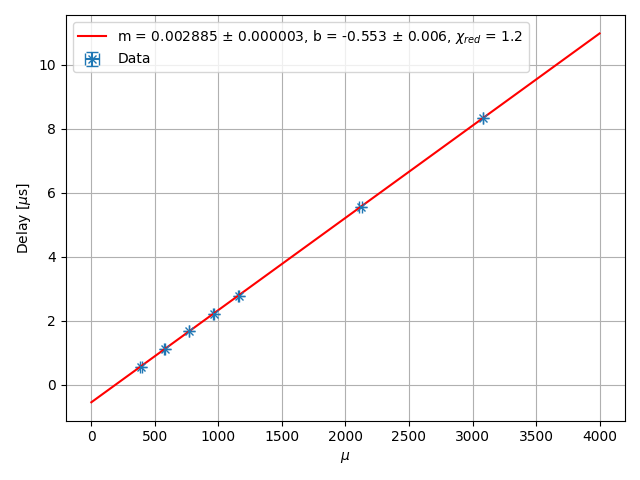

In [23]:
mean_time_calibration_fg = peaks_calibration_time_fg
error_mean_time_calibration_fg = dpeaks_calibration_time_fg

data_fg = RealData(mean_time_calibration_fg, delay_values_us_fg,
                sx=error_mean_time_calibration_fg, sy=delay_unc_us_fg) 

# Modell und ODR-Objekt
linear_model = Model(linear_func)
odr = ODR(data_fg, linear_model, beta0=[0.001, 0])  # Startwerte m, b

# Fit durchführen
output_fg = odr.run()

m_odr_fg, b_odr_fg = output_fg.beta
dm_odr_fg, db_odr_fg = np.sqrt(np.diag(output_fg.cov_beta))

print(f"Slope = {m_odr_fg:.6f} ± {dm_odr_fg:.6f}")
print(f"Intercept = {b_odr_fg:.2f} ± {db_odr_fg:.2f}")

# Fit-Kurve für Plot
x_fit_fg = np.linspace(0, 4000, 10000)
y_fit_fg = linear_func([m_odr_fg, b_odr_fg], x_fit_fg)

# Plot
plt.figure()
plt.errorbar(mean_time_calibration_fg, delay_values_us_fg, xerr=error_mean_time_calibration_fg, yerr = delay_unc_us_fg, fmt='x', capsize=4, label='Data')
plt.plot(x_fit_fg, y_fit_fg, 'r-', label=f'm = {m_odr_fg:.6f} ± {dm_odr_fg:.6f}, b = {b_odr_fg:.3f} ± {db_odr_fg:.3f}, $\chi_{{red}}$ = {output_fg.res_var:.1f}')
plt.xlabel('$\mu$')
plt.ylabel('Delay [$\mu$s]')
#plt.ylim(0, 11)
# plt.xlim(2000, 4000)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#### All calibration data together

Combined slope = 0.002912 ± 0.000001
Combined intercept = -0.339 ± 0.003


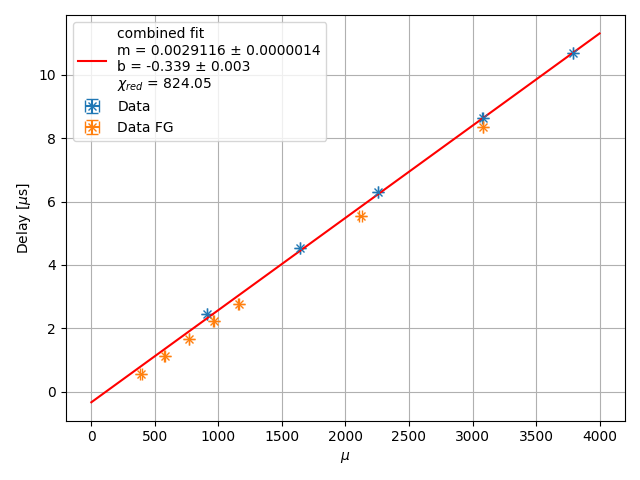

In [24]:
x_all = np.concatenate([mean_time_calibration, mean_time_calibration_fg])
y_all = np.concatenate([delay_values_us, delay_values_us_fg])

sx_all = np.concatenate([error_mean_time_calibration, error_mean_time_calibration_fg])
sy_all = np.concatenate([delay_unc_us, delay_unc_us_fg])

data_all = RealData(x_all, y_all, sx=sx_all, sy=sy_all)

linear_model = Model(linear_func)
odr_all = ODR(data_all, linear_model, beta0=[0.001, 0])

output_all = odr_all.run()

m_all, b_all = output_all.beta
dm_all, db_all = np.sqrt(np.diag(output_all.cov_beta))

print(f"Combined slope = {m_all:.6f} ± {dm_all:.6f}")
print(f"Combined intercept = {b_all:.3f} ± {db_all:.3f}")

x_fit_all = np.linspace(0, 4000, 10000)
y_fit_all = linear_func([m_all, b_all], x_fit_all)


plt.figure()

plt.errorbar(mean_time_calibration, delay_values_us,
             xerr=error_mean_time_calibration, yerr=delay_unc_us,
             fmt='x', capsize=4, label='Data')

plt.errorbar(mean_time_calibration_fg, delay_values_us_fg,
             xerr=error_mean_time_calibration_fg, yerr=delay_unc_us_fg,
             fmt='x', capsize=4, label='Data FG')

plt.plot(x_fit_all, y_fit_all, 'r-',
         label=f'combined fit\nm = {m_all:.7f} ± {dm_all:.7f}\nb = {b_all:.3f} ± {db_all:.3f}\n$\chi_{{red}}$ = {output_all.res_var:.2f}')

plt.xlabel('$\\mu$')
plt.ylabel('Delay [$\\mu$s]')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## Background

<ErrorbarContainer object of 3 artists>

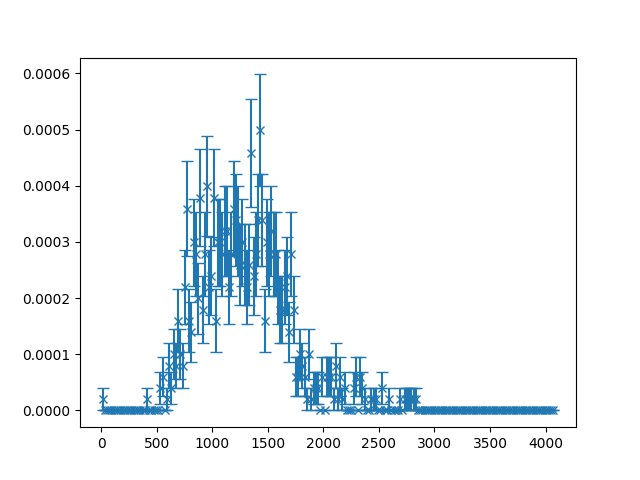

In [25]:
# background beta spectrum

beta_background = read_data('RawData/spectrum/beta_background_3.TKA', cutoff=2).astype(float)
beta_background_time = read_data('RawData/spectrum/beta_background_3.TKA', cutoff=0)[0]
beta_background_channel = np.arange(2, 2 + len(beta_background))
beta_background_time = np.float64(beta_background_time)

beta_background_uncertainty = uncertainty_rate(beta_background, beta_background_time, dt_spectrometer) 
beta_background = beta_background/beta_background_time

# bin the data to reduce noise
binned_beta_background_channel, binned_beta_background, binned_error_beta_background = bin_data_poisson(
    beta_background_channel, beta_background, yerr = beta_background_uncertainty, bin_width = 20)

# plot the binned data
plt.figure()
plt.errorbar(binned_beta_background_channel, binned_beta_background, yerr=binned_error_beta_background, fmt='x', capsize=4, label='Data')

<ErrorbarContainer object of 3 artists>

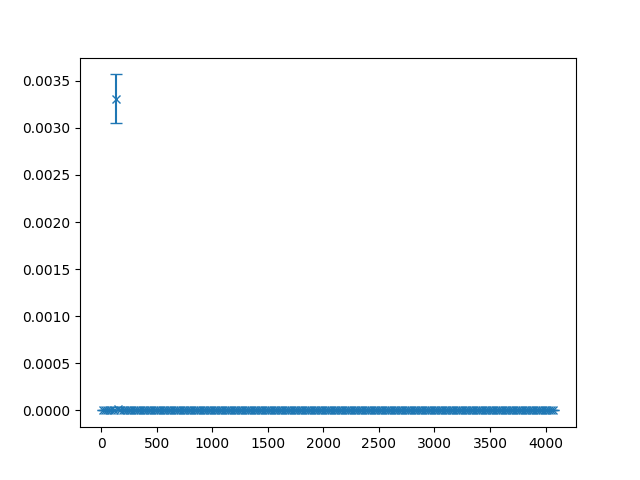

In [26]:
# background time spectrum

time_background = read_data('RawData/spectrum/time_background_3.TKA', cutoff=2).astype(float)
time_background_time = read_data('RawData/spectrum/time_background_3.TKA', cutoff=0)[0]
time_background_channel = np.arange(2, 2 + len(time_background))
time_background_time = np.float64(time_background_time)

time_background_uncertainty = uncertainty_rate(time_background, time_background_time, dt_spectrometer) 
time_background = time_background/time_background_time

# bin the data to reduce noise
binned_time_background_channel, binned_time_background, binned_error_time_background = bin_data_poisson(
    time_background_channel, time_background, yerr = time_background_uncertainty, bin_width = 20)

# plot the binned data
plt.figure()
plt.errorbar(binned_time_background_channel, binned_time_background, yerr=binned_error_time_background, fmt='x', capsize=4, label='Data')

## Time Spectrum

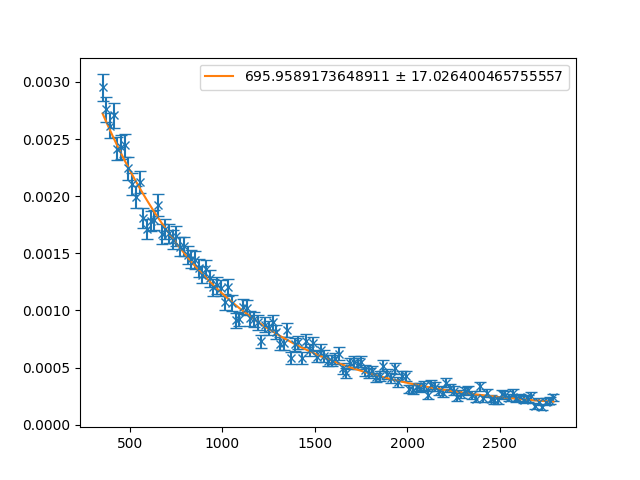

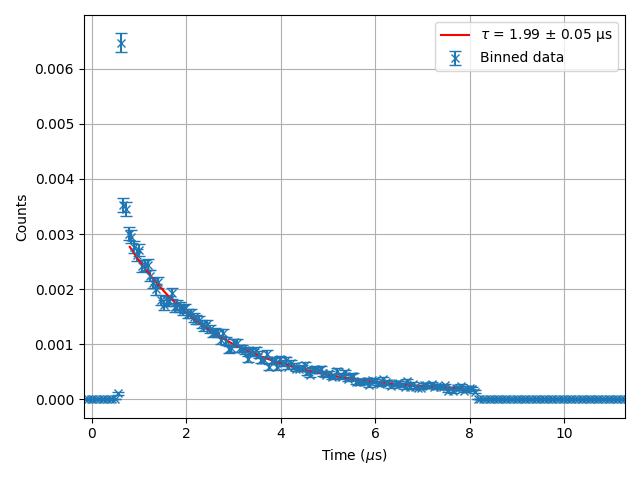

In [37]:
# --- Load the raw time spectrum data ---
time_spectrum = read_data('RawData/spectrum/time_signal_5.TKA', cutoff=2).astype(float)
time_spectrum_time = read_data('RawData/spectrum/time_signal_5.TKA', cutoff=0)[0]
time_spectrum_channel = np.arange(2, 2 + len(time_spectrum))
# print(np.where(time_spectrum > 0))
time_spectrum_time = np.float64(time_spectrum_time)

time_spectrum_uncertainty = uncertainty_rate(time_spectrum, time_spectrum_time, dt_spectrometer) 
time_spectrum = time_spectrum/time_spectrum_time


# --- Bin the data to reduce noise ---
binned_time_spectrum_channel, binned_time_spectrum, binned_error_time_spectrum = bin_data_poisson(
    time_spectrum_channel, time_spectrum, yerr = time_spectrum_uncertainty, bin_width = 20)


# --- Convert channels to time using linear calibration ---
# mu_to_delay_with_error returns (time in µs, uncertainty in time)
time_spectrum_time_calibrated, time_spectrum_time_error = mu_to_delay_with_error(
    binned_time_spectrum_channel, m_odr, b_odr, dm_odr, db_odr
)

# --- Fit an exponential decay with offset ---
# Mask to select fitting region (in channel units)
mask_time = (
    (binned_time_spectrum_channel >= 340) &
    (binned_time_spectrum_channel <= 2800) &
    (binned_error_time_spectrum > 0) &
    np.isfinite(binned_error_time_spectrum) &
    np.isfinite(binned_time_spectrum)
)


popt_time_spectrum, pcov_time_spectrum = curve_fit(
    exp_decay_with_offset,
    binned_time_spectrum_channel[mask_time],
    binned_time_spectrum[mask_time],
    sigma=binned_error_time_spectrum[mask_time],
    p0=[145, 350, 0]  # initial guess: [A, tau_channel, C]
)


plt.figure()
plt.errorbar(binned_time_spectrum_channel[mask_time], binned_time_spectrum[mask_time], yerr=binned_error_time_spectrum[mask_time], fmt='x', capsize=4)
plt.plot(binned_time_spectrum_channel[mask_time], exp_decay_with_offset(binned_time_spectrum_channel[mask_time], *popt_time_spectrum), 
         label = f'{popt_time_spectrum[1]} $\pm$ {np.sqrt(np.diag(pcov_time_spectrum))[1]}')
plt.legend()

# Extract fit parameter errors
perr_time_spectrum = np.sqrt(np.diag(pcov_time_spectrum))

# --- Convert fit x-values to time for plotting ---
x_fit_time_spectrum = np.linspace(340, 2800, 10000)
x_fit_time_calibrated, _ = mu_to_delay_with_error(
    x_fit_time_spectrum, m_odr, b_odr, dm_odr, db_odr
)

# --- Convert the exponential decay constant tau to µs ---
tau_channel = popt_time_spectrum[1]
tau_time = m_odr * tau_channel              # linear scale factor
tau_time_error = np.sqrt(
    (tau_channel * dm_odr)**2 +
    (m_odr * perr_time_spectrum[1])**2
)       # propagate slope uncertainty only

# --- Plotting ---
plt.figure()

# Plot binned data with Poisson error bars (y-error)
plt.errorbar(
    time_spectrum_time_calibrated,
    binned_time_spectrum,
    yerr=binned_error_time_spectrum,
    fmt='x',
    capsize=4,
    label='Binned data'
)

# Plot fitted exponential on calibrated time axis
plt.plot(
    x_fit_time_calibrated,
    exp_decay_with_offset(x_fit_time_spectrum, *popt_time_spectrum),
    'r-',
    label=f'$\\tau$ = {tau_time:.2f} ± {tau_time_error:.2f} µs'
)

plt.xlabel("Time ($\mu$s)")
plt.ylabel("Counts")
plt.xlim(mu_to_delay_with_error(0, m_odr, b_odr, dm_odr, db_odr)[0],
         mu_to_delay_with_error(4000, m_odr, b_odr, dm_odr, db_odr)[0])
plt.grid()
plt.legend()
plt.tight_layout()

## $\beta$ Spectrum

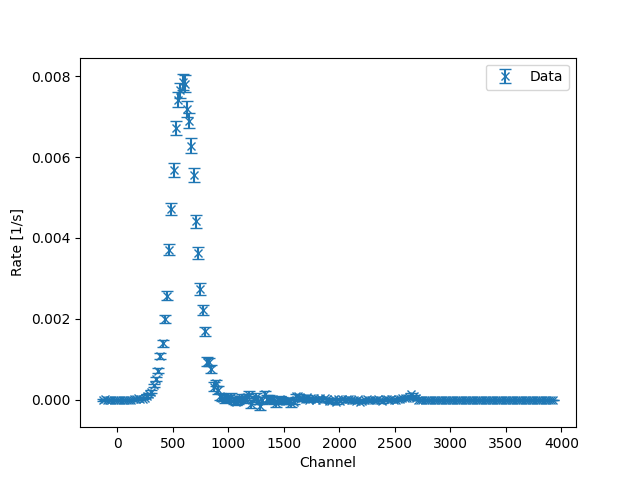

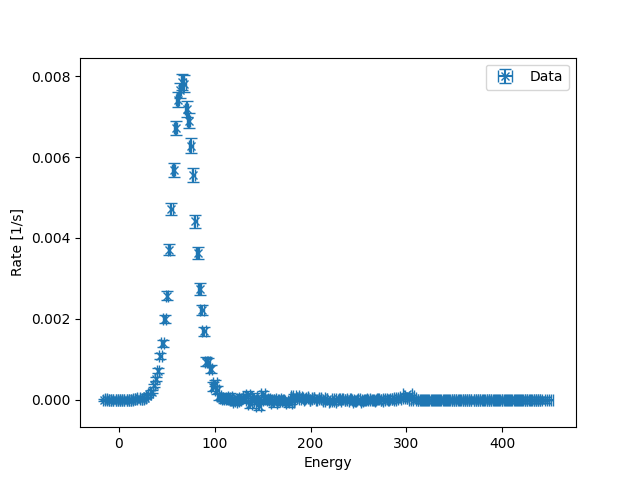

In [31]:
beta_spectrum = read_data('RawData/spectrum/beta_signal_5.TKA', cutoff = 2)
beta_spectrum_channel = np.arange(2, 2 + len(time_spectrum)) - pedestal_100
dbeta_spectrum_channel = dpedestal_100
beta_spectrum_time = read_data('RawData/spectrum/beta_signal_5.TKA', cutoff = 0)[0]
beta_spectrum_time = np.float64(beta_spectrum_time)




beta_spectrum_uncertainty = uncertainty_rate(beta_spectrum, beta_spectrum_time, dt_spectrometer) 
beta_spectrum = beta_spectrum/beta_spectrum_time

# background correct beta spectrum
beta_spectrum = beta_spectrum - beta_background
beta_spectrum_uncertainty = np.sqrt(beta_spectrum_uncertainty**2 + beta_background_uncertainty**2)


binned_beta_spectrum_channel, binned_beta_spectrum, binned_error_beta_spectrum = bin_data_poisson(beta_spectrum_channel, beta_spectrum, beta_spectrum_uncertainty, 20)

binned_beta_spectrum_channel_energy = channel_to_energy_with_error(binned_beta_spectrum_channel, m_energycalib, b_energycalib, dm_energycalib, db_energycalib, dpedestal_100)

plt.figure()
plt.errorbar(binned_beta_spectrum_channel, binned_beta_spectrum, yerr=binned_error_beta_spectrum, fmt='x', capsize=4, label='Data')
plt.xlabel('Channel')
plt.ylabel('Rate [1/s]')
plt.legend()


plt.figure()
plt.errorbar(binned_beta_spectrum_channel_energy[0], binned_beta_spectrum, xerr = binned_beta_spectrum_channel_energy[1], yerr=binned_error_beta_spectrum, fmt='x', capsize=4, label = 'Data')
plt.xlabel('Energy')
plt.ylabel('Rate [1/s]')
plt.legend()

### Fermi-Kurie Plot

In [32]:
# general function

def fermi_kurie(N, E=None, sigma_N=None, sigma_E=None):
    """
    Berechnet die Fermi-Kurie-Funktion F(E) = sqrt(N)/E aus einem Beta-Spektrum,
    inklusive Fehlerfortpflanzung für N und E.

    Parameter:
    -----------
    N : array_like
        Anzahl der Ereignisse pro Kanal (oder Energiebin)
    E : array_like, optional
        Energie pro Kanal. Wenn None, werden die Indizes als Energie verwendet.
    sigma_N : array_like, optional
        Unsicherheit in N. Wenn None, wird sqrt(N) angenommen (Poisson).
    sigma_E : array_like, optional
        Unsicherheit in E. Wenn None, wird 0 angenommen.

    Rückgabe:
    ---------
    F : np.ndarray
        Fermi-Kurie-Funktion F(E)
    F_error : np.ndarray
        Unsicherheit von F(E)
    """
    
    N = np.asarray(N, dtype=float)
    
    if E is None:
        E = np.arange(len(N))
    else:
        E = np.asarray(E, dtype=float)
    
    if sigma_N is None:
        sigma_N = np.sqrt(N)
    else:
        sigma_N = np.asarray(sigma_N, dtype=float)
    
    if sigma_E is None:
        sigma_E = np.zeros_like(E)
    else:
        sigma_E = np.asarray(sigma_E, dtype=float)
    
    # Maske für gültige E > 0
    mask = E > 0
    F = np.zeros_like(N)
    F_error = np.zeros_like(N)
    
    F[mask] = np.sqrt(N[mask]) / E[mask]
    
    # Fehlerfortpflanzung
    F_error[mask] = np.sqrt( (0.5 * sigma_N[mask] / np.sqrt(N[mask]) / E[mask])**2 + 
                             (np.sqrt(N[mask]) / E[mask]**2 * sigma_E[mask])**2 )
    
    F_error[np.isnan(F_error)] = 0
    
    return F, F_error

C:\Users\tabit\AppData\Local\Temp\ipykernel_24276\2734078024.py:49: RuntimeWarning: invalid value encountered in sqrt
  F[mask] = np.sqrt(N[mask]) / E[mask]
C:\Users\tabit\AppData\Local\Temp\ipykernel_24276\2734078024.py:52: RuntimeWarning: invalid value encountered in sqrt
  F_error[mask] = np.sqrt( (0.5 * sigma_N[mask] / np.sqrt(N[mask]) / E[mask])**2 +
C:\Users\tabit\AppData\Local\Temp\ipykernel_24276\2734078024.py:52: RuntimeWarning: invalid value encountered in divide
  F_error[mask] = np.sqrt( (0.5 * sigma_N[mask] / np.sqrt(N[mask]) / E[mask])**2 +
C:\Users\tabit\AppData\Local\Temp\ipykernel_24276\2734078024.py:53: RuntimeWarning: invalid value encountered in sqrt
  (np.sqrt(N[mask]) / E[mask]**2 * sigma_E[mask])**2 )


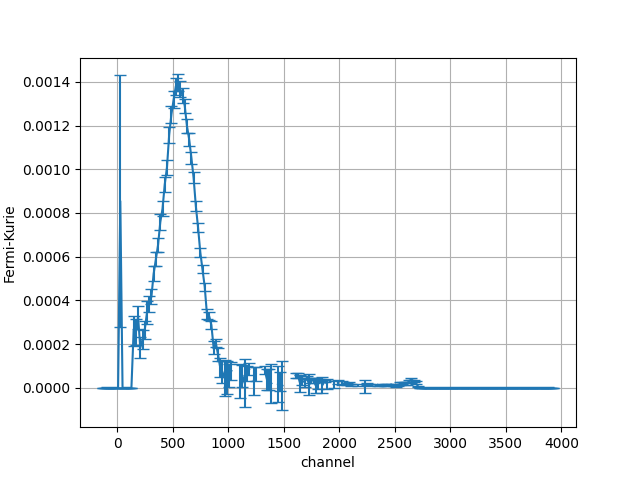

In [33]:
F, F_error = fermi_kurie(binned_beta_spectrum, 
                         E=binned_beta_spectrum_channel_energy[0], 
                         sigma_N=binned_error_beta_spectrum, 
                         sigma_E=binned_beta_spectrum_channel_energy[1])

plt.figure()
plt.errorbar(binned_beta_spectrum_channel, F, yerr=F_error, fmt='', capsize=4)

plt.xlabel('channel')
plt.ylabel('Fermi-Kurie')
#plt.ylim(0, 0.04)
plt.grid(True)
plt.show()

### Fermi-Flank

A = 0.01, E0 = 693.48, deltaE = 55.91
(78.17208903071906, 6.540202766593343)
muon mass = 156.34417806143813 $\pm$ 2.9996931857918843 MeV


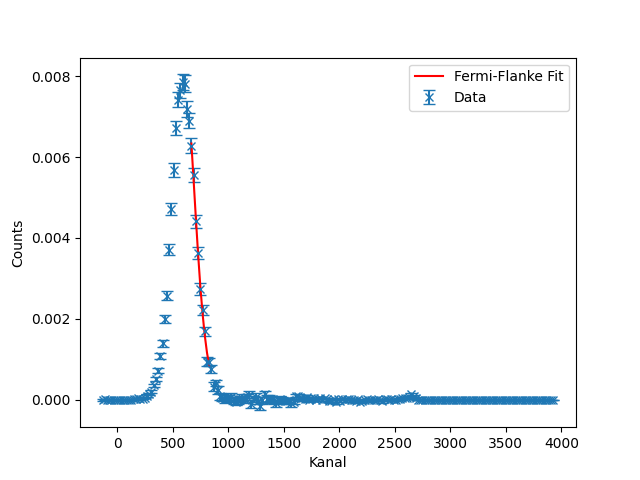

In [34]:
# --- Fermi-Flanke Funktion ---
def fermi_edge(E, A, E0, deltaE):
    return A / (1 + np.exp((E - E0)/deltaE))

# --- Auswahl des Bereichs am Edge ---
# z.B. die letzten 100 Kanäle des binned Spektrums
edge_mask = (binned_beta_spectrum_channel > 660) & (binned_beta_spectrum_channel < 840)
E_edge = binned_beta_spectrum_channel[edge_mask]
N_edge = binned_beta_spectrum[edge_mask]
err_edge = binned_error_beta_spectrum[edge_mask]

# --- Initial Guesses ---
A0 = N_edge.max()
E0_0 = E_edge[np.argmax(N_edge)]  # oder einfach max(E_edge)
deltaE0 = 5  # grobe Breite der Flanke

p0 = [A0, E0_0, deltaE0]

# --- Fit ---
params, cov = curve_fit(fermi_edge, E_edge, N_edge, sigma=err_edge, p0=p0, absolute_sigma=True)

A_fit, E0_fit, deltaE_fit = params
print(f"A = {A_fit:.2f}, E0 = {E0_fit:.2f}, deltaE = {deltaE_fit:.2f}")
print(channel_to_energy_with_error(E0_fit, dchannel = deltaE_fit))
print(f'muon mass = {2* channel_to_energy_with_error(E0_fit)[0]} $\pm$ {2* channel_to_energy_with_error(E0_fit)[1]} MeV')

# --- Plot ---
plt.figure()
plt.errorbar(binned_beta_spectrum_channel, binned_beta_spectrum, yerr=binned_error_beta_spectrum,
             fmt='x', capsize=4, label='Data')
plt.plot(E_edge, fermi_edge(E_edge, *params), 'r-', label='Fermi-Flanke Fit')
plt.xlabel('Kanal')
plt.ylabel('Counts')
plt.legend()
plt.show()

